# Investigate k

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
client = start_cluster(8, 24)
client_ip_and_port(client)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41027 instead
  warnings.warn(
2025-06-25 10:54:52,278 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f95f7353b00>>, <Task finished name='Task-16' coro=<SpecCluster._correct_state_internal() done, defined at /uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/deploy/spec.py:346> exception=RuntimeError('Command exited with non-zero exit code.\nExit code: 1\nCommand:\nsbatch /scratch/local/u1037042/4916786/tmptzs72nge.sh\nstdout:\n\nstderr:\nsbatch: error: Batch job submission failed: Invalid qos specification\n\n')>)
Traceback (most recent call last

10.242.76.198:41027


In [3]:
# paths
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES")
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES/net_solar_dsw3/wy2022")
# net_dswrf.MST.20211110.nc
SHARED_STORE2 = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit")
# toposplit_20220218.nc

SHARED_STORE_RUN = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit")
# erw_spires_dsw3_dlwrf/wy2022/erw_50m

SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')
SNOTEL_DIR = DATA_DIR.joinpath( 'Snotel')


year = 2022
water_year = f'wy{year}'

In [4]:
# focus on IRWIN
from pathlib import Path, PurePath
snotel_sites = SnotelLocations()
snotel_sites.load_from_json(SNOTEL_DIR / 'site-locations/snotel_sites.json')
snotel_sites.Irwin

SnotelSite(name='Irwin', lon=[317131], lat=[4306375])

In [5]:
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

# file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit/toposplit_*.nc'
file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit_2022/toposplit_*.nc'

# file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/net_solar.nc"

HRRR_solar = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',
    parallel=True, chunks={'time': 24}, # 'y' :10, 'x': 10},
)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46743 instead
  warnings.warn(


In [6]:
irwin_dsw1 = HRRR_solar.dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw3 = HRRR_solar.dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_k = HRRR_solar.k.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


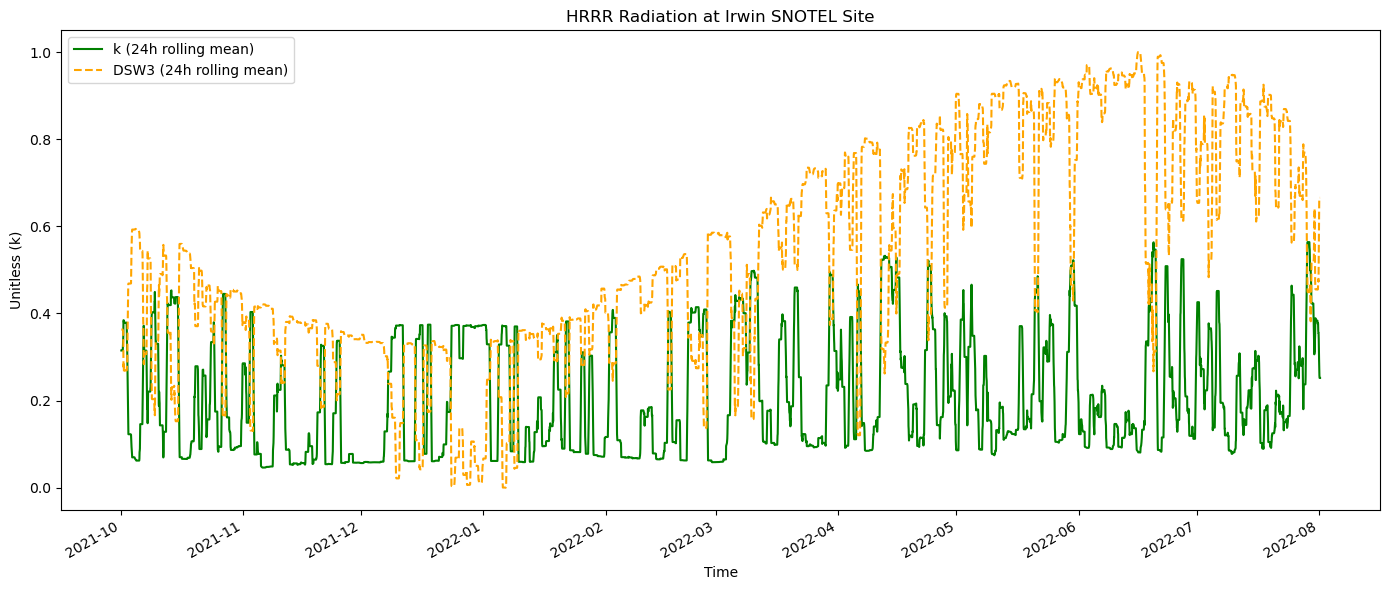

In [7]:
import matplotlib.pyplot as plt

win = 24
# win = 12

# Compute 24-hour rolling mean (assuming hourly data and irwin_k is a Series)
irwin_k_rolling = irwin_k.rolling(time=win).mean()
irwin_dsw3_rolling = irwin_dsw3.rolling(time=win).mean()

scaled_dsw3 = (irwin_dsw3_rolling - irwin_dsw3_rolling.min()) / (irwin_dsw3_rolling.max() - irwin_dsw3_rolling.min())


# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the 24-hour rolling mean
ax.plot(irwin_k.time, irwin_k_rolling, label='k (24h rolling mean)', color='green')
ax.plot(irwin_dsw3.time, scaled_dsw3, label='DSW3 (24h rolling mean)', color='orange', linestyle='--')

# Formatting
ax.set_title('HRRR Radiation at Irwin SNOTEL Site')
ax.set_xlabel('Time')
ax.set_ylabel('Unitless (k)')
ax.legend()
# ax.grid(True)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

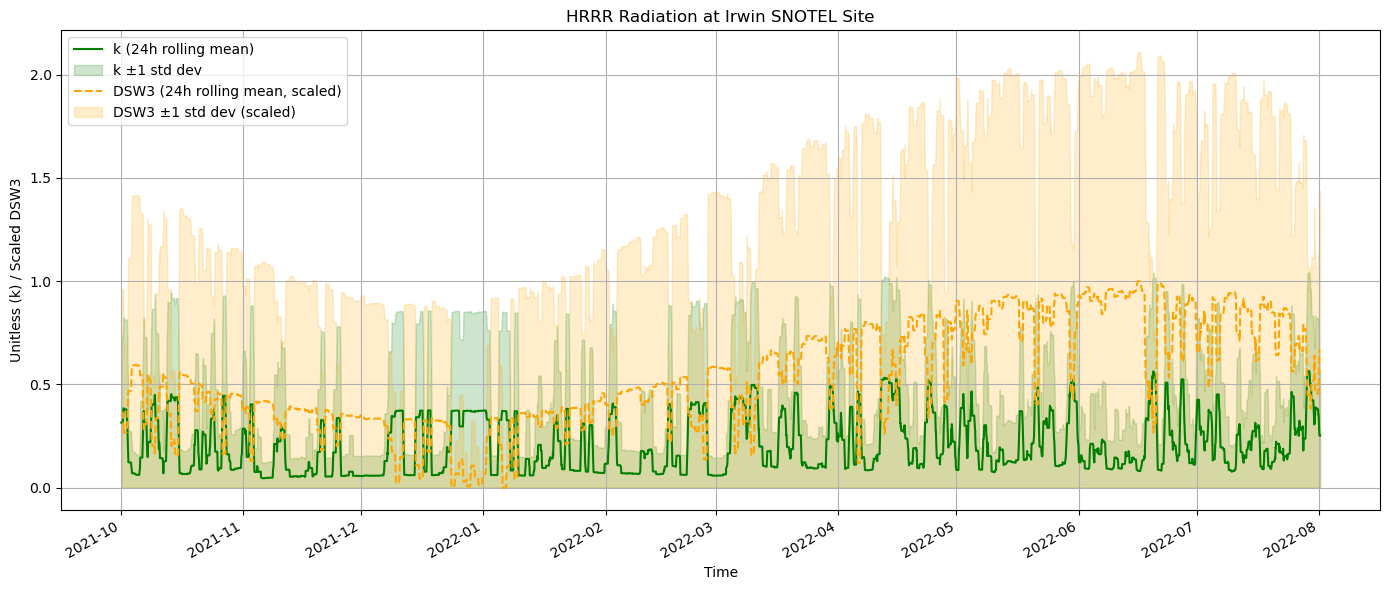

In [8]:
import matplotlib.pyplot as plt

# Compute 24-hour rolling mean and standard deviation
irwin_k_rolling = irwin_k.rolling(time=24).mean()
irwin_k_std = irwin_k.rolling(time=24).std()

irwin_dsw3_rolling = irwin_dsw3.rolling(time=24).mean()
irwin_dsw3_std = irwin_dsw3.rolling(time=24).std()

# Scale DSW3 rolling mean between 0 and 1
scaled_dsw3 = (irwin_dsw3_rolling - irwin_dsw3_rolling.min()) / (irwin_dsw3_rolling.max() - irwin_dsw3_rolling.min())

# Scale the DSW3 std accordingly (optional but typically useful)
scaled_dsw3_std = irwin_dsw3_std / (irwin_dsw3_rolling.max() - irwin_dsw3_rolling.min())

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Plot k and its standard deviation shading
ax.plot(irwin_k.time, irwin_k_rolling, label='k (24h rolling mean)', color='green')
ax.fill_between(irwin_k.time, 0, irwin_k_rolling + irwin_k_std, 
                color='green', alpha=0.2, label='k ±1 std dev')

# Plot DSW3 and its standard deviation shading
ax.plot(irwin_dsw3.time, scaled_dsw3, label='DSW3 (24h rolling mean, scaled)', color='orange', linestyle='--')
ax.fill_between(irwin_dsw3.time, 0, scaled_dsw3 + scaled_dsw3_std, 
                color='orange', alpha=0.2, label='DSW3 ±1 std dev (scaled)')

# Formatting
ax.set_title('HRRR Radiation at Irwin SNOTEL Site')
ax.set_xlabel('Time')
ax.set_ylabel('Unitless (k) / Scaled DSW3')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


/scratch/local/u1037042/4837636/ipykernel_1600159/1350857822.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='k', data=df, palette='viridis')


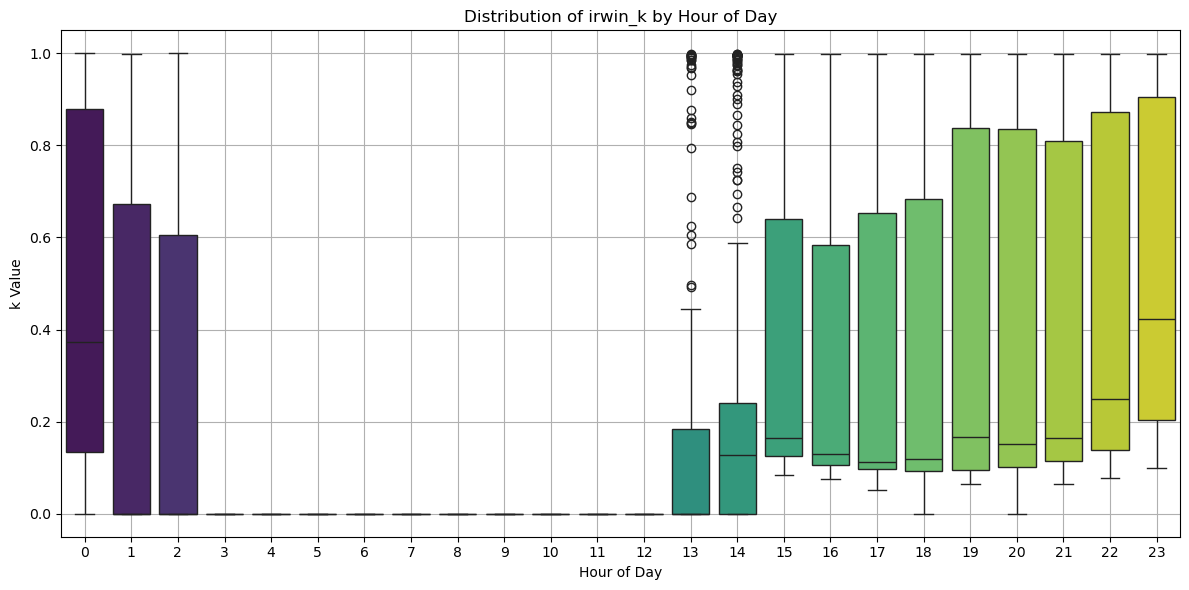

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure irwin_k is a pandas Series and time is a datetime Series or datetime index
# Combine into one DataFrame for easy handling
df = pd.DataFrame({
    'time': irwin_k.time,
    'k': irwin_k.values  # or just irwin_k if already a Series
})

# Convert time column to datetime if not already
df['time'] = pd.to_datetime(df['time'])

# Extract hour from timestamp
df['hour'] = df['time'].dt.hour

# Create boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='k', data=df, palette='viridis')

# Formatting
plt.title('Distribution of irwin_k by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('k Value')
plt.grid(True)
plt.tight_layout()
plt.show()

/scratch/local/u1037042/4837636/ipykernel_1600159/3928665801.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='k', data=df, palette='viridis')


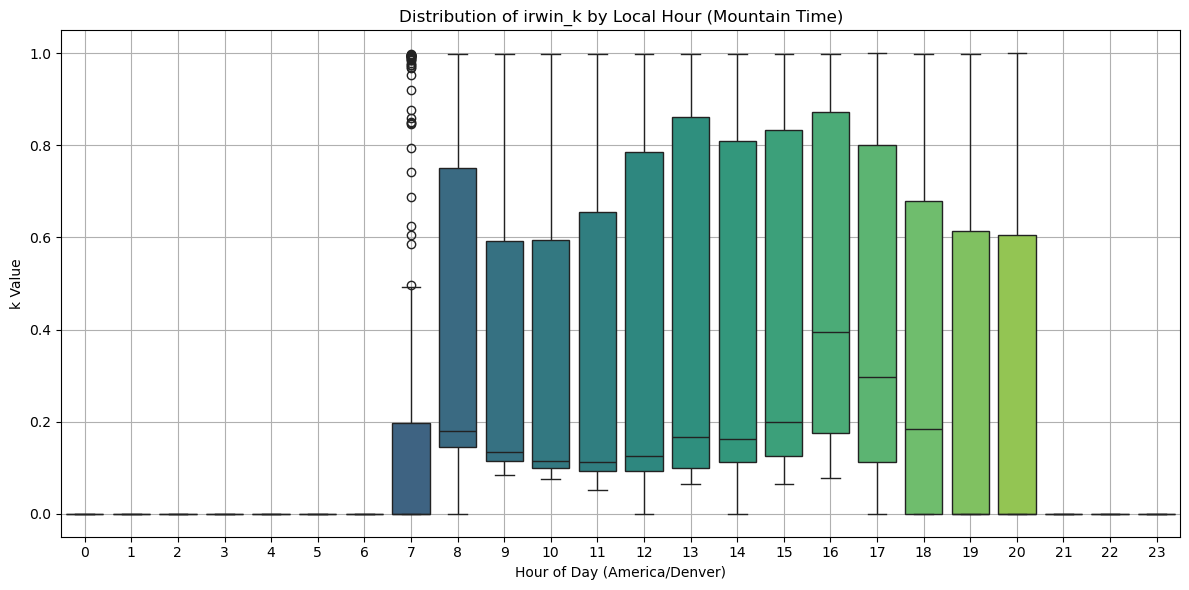

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pytz  # for timezone conversion

# Combine into one DataFrame
df = pd.DataFrame({
    'time': pd.to_datetime(irwin_k.time),
    'k': irwin_k.values
})

# Localize to UTC if not already, then convert to Mountain Time
df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

# Extract hour in local time
df['hour'] = df['time'].dt.hour

# Create boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='k', data=df, palette='viridis')

# Formatting
plt.title('Distribution of irwin_k by Local Hour (Mountain Time)')
plt.xlabel('Hour of Day (America/Denver)')
plt.ylabel('k Value')
plt.grid(True)
plt.tight_layout()
plt.show()


/scratch/local/u1037042/4837636/ipykernel_1600159/1687713172.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='k', data=df, palette='viridis')


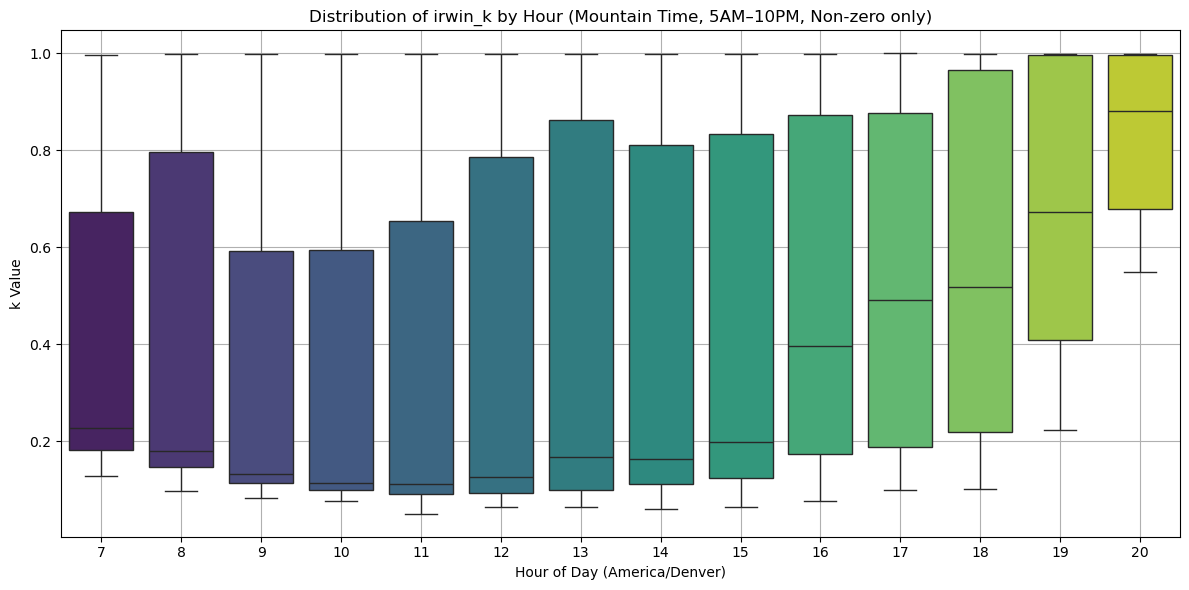

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pytz

# Combine into one DataFrame
df = pd.DataFrame({
    'time': pd.to_datetime(irwin_k.time),
    'k': irwin_k.values
})

# Localize to UTC and convert to Mountain Time
df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

# Filter: Remove NaNs and zeros
df = df.dropna(subset=['k'])
df = df[df['k'] != 0]

# Extract hour in local time
df['hour'] = df['time'].dt.hour

# Filter for hours between 5 AM and 10 PM
df = df[(df['hour'] >= 4) & (df['hour'] <= 22)]

# Create boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='k', data=df, palette='viridis')

# Formatting
plt.title('Distribution of irwin_k by Hour (Mountain Time, 5AM–10PM, Non-zero only)')
plt.xlabel('Hour of Day (America/Denver)')
plt.ylabel('k Value')
plt.grid(True)
plt.tight_layout()
plt.show()


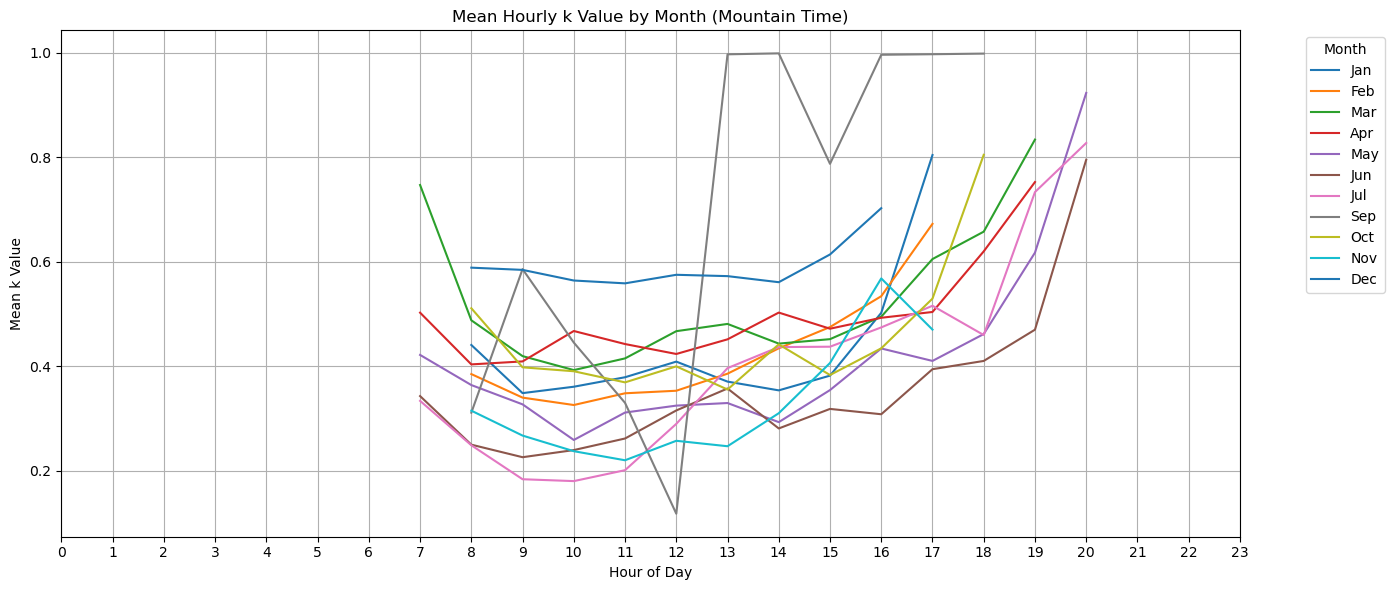

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the DataFrame
df = pd.DataFrame({
    'time': pd.to_datetime(irwin_k.time),
    'k': irwin_k.values
})

# Convert time to Mountain Time (America/Denver)
df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

# Drop NaN and zero values
df = df.dropna(subset=['k'])
df = df[df['k'] != 0]

# Extract hour and month
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

# Group by month and hour, then compute the mean
grouped = df.groupby(['month', 'hour'])['k'].mean().reset_index()

# Optional: Map month numbers to names
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
grouped['month'] = grouped['month'].map(month_names)

# Create the plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped, x='hour', y='k', hue='month', palette='tab10')

# Formatting
plt.title('Mean Hourly k Value by Month (Mountain Time)')
plt.xlabel('Hour of Day')
plt.ylabel('Mean k Value')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


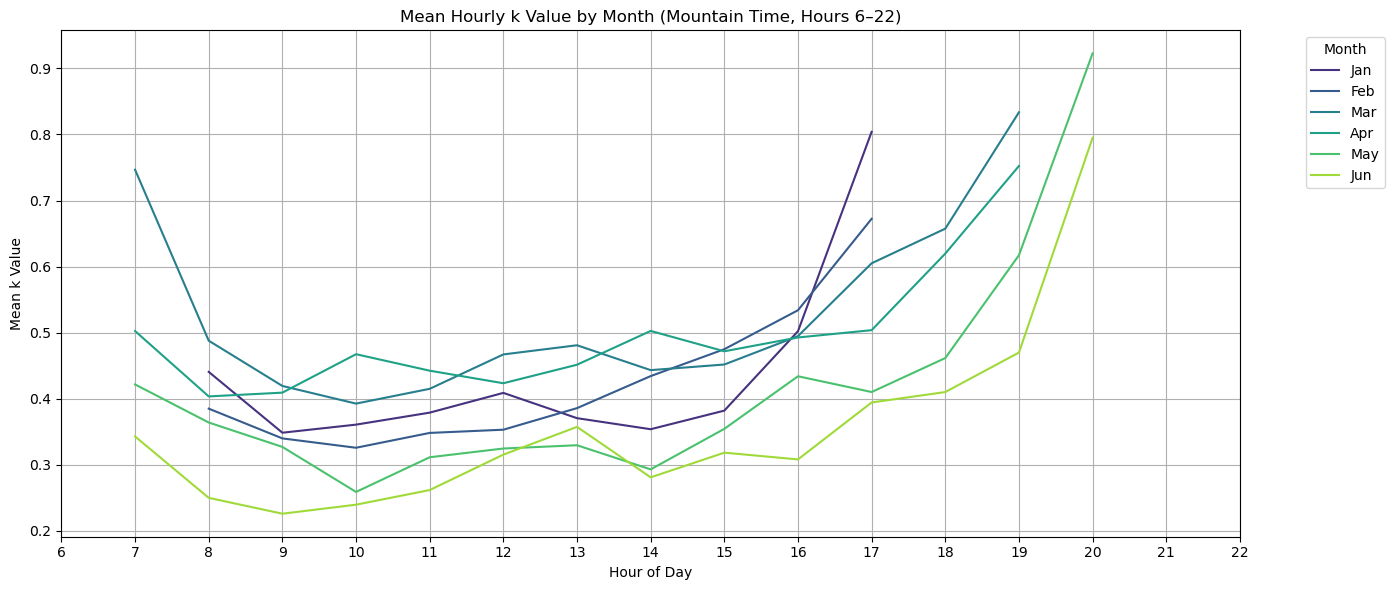

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the DataFrame
df = pd.DataFrame({
    'time': pd.to_datetime(irwin_k.time),
    'k': irwin_k.values
})

# Convert to Mountain Time
df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

# Clean data: remove NaNs and zeros
df = df.dropna(subset=['k'])
df = df[df['k'] != 0]

# Extract hour and month
df['hour'] = df['time'].dt.hour
df['month_num'] = df['time'].dt.month

# Map and filter desired months
month_map = {
    10: 'Oct', 11: 'Nov', 12: 'Dec',
     1: 'Jan',  2: 'Feb',  3: 'Mar',
     4: 'Apr',  5: 'May',  6: 'Jun'
}
df = df[df['month_num'].isin(month_map.keys())]
df['month'] = df['month_num'].map(month_map)

# Filter hours: only 6 to 22
df = df[(df['hour'] >= 6) & (df['hour'] <= 22)]

# Group by month and hour
grouped = df.groupby(['month', 'hour'])['k'].mean().reset_index()

# Set month order
# month_order = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
grouped['month'] = pd.Categorical(grouped['month'], categories=month_order, ordered=True)

# Sort the data
grouped = grouped.sort_values(['month', 'hour'])

# Create a gradient color palette
colors = sns.color_palette("viridis", n_colors=len(month_order))

# Plot
plt.figure(figsize=(14, 6))
for i, month in enumerate(month_order):
    month_data = grouped[grouped['month'] == month]
    plt.plot(month_data['hour'], month_data['k'], label=month, color=colors[i])

# Formatting
plt.title('Mean Hourly k Value by Month (Mountain Time, Hours 6–22)')
plt.xlabel('Hour of Day')
plt.ylabel('Mean k Value')
plt.xticks(range(6, 23))
plt.grid(True)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

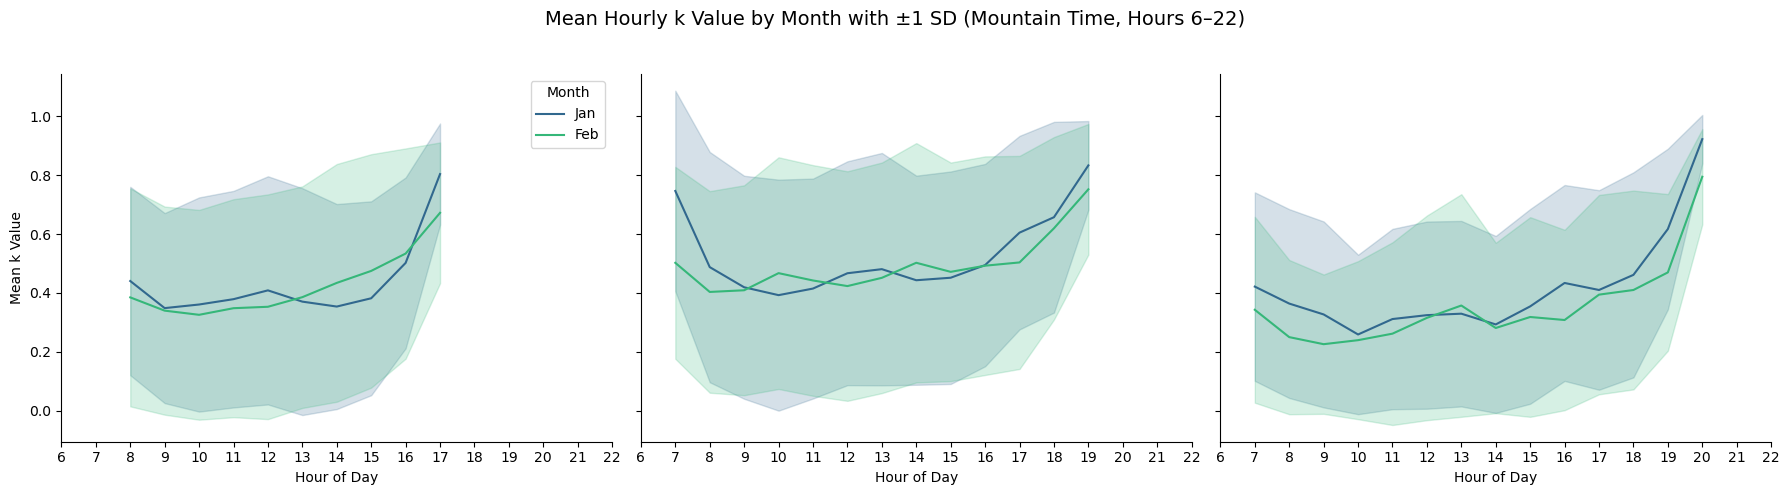

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare DataFrame
df = pd.DataFrame({
    'time': pd.to_datetime(irwin_k.time),
    'k': irwin_k.values
})

# Convert to Mountain Time
df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

# Clean data
df = df.dropna(subset=['k'])
df = df[df['k'] != 0]

# Extract hour and month
df['hour'] = df['time'].dt.hour
df['month_num'] = df['time'].dt.month

# Define target months and mapping
month_map = {
    1: 'Jan', 2: 'Feb',
    3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun'
}
df = df[df['month_num'].isin(month_map.keys())]
df['month'] = df['month_num'].map(month_map)

# Filter hours
df = df[(df['hour'] >= 6) & (df['hour'] <= 22)]

# Compute mean and std grouped by month and hour
grouped = df.groupby(['month', 'hour'])['k'].agg(['mean', 'std']).reset_index()

# Ensure correct order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
grouped['month'] = pd.Categorical(grouped['month'], categories=month_order, ordered=True)
grouped = grouped.sort_values(['month', 'hour'])

# Create subplot layout: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Month groupings for each subplot
panels = {
    0: ['Jan', 'Feb'],
    1: ['Mar', 'Apr'],
    2: ['May', 'Jun']
}

# Color palette
colors = sns.color_palette("viridis", n_colors=2)

# Plot each panel
for i, (ax_idx, months) in enumerate(panels.items()):
    ax = axes[ax_idx]
    for j, month in enumerate(months):
        month_data = grouped[grouped['month'] == month]
        ax.plot(month_data['hour'], month_data['mean'], label=month, color=colors[j])
        ax.fill_between(
            month_data['hour'],
            month_data['mean'] - month_data['std'],
            month_data['mean'] + month_data['std'],
            alpha=0.2,
            color=colors[j]
        )
    
    # Formatting
    # ax.set_title(f"{' & '.join(months)}")
    ax.set_xlabel("Hour of Day")
    ax.set_xticks(range(6, 23))
    ax.set_xlim(6, 22)
    ax.set_facecolor('white')  # Remove grid background
    ax.tick_params(axis='both', which='both', direction='out')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared Y label
axes[0].set_ylabel("Mean k Value")

# Add legend to first panel
axes[0].legend(title='Month')

plt.suptitle("Mean Hourly k Value by Month with ±1 SD (Mountain Time, Hours 6–22)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


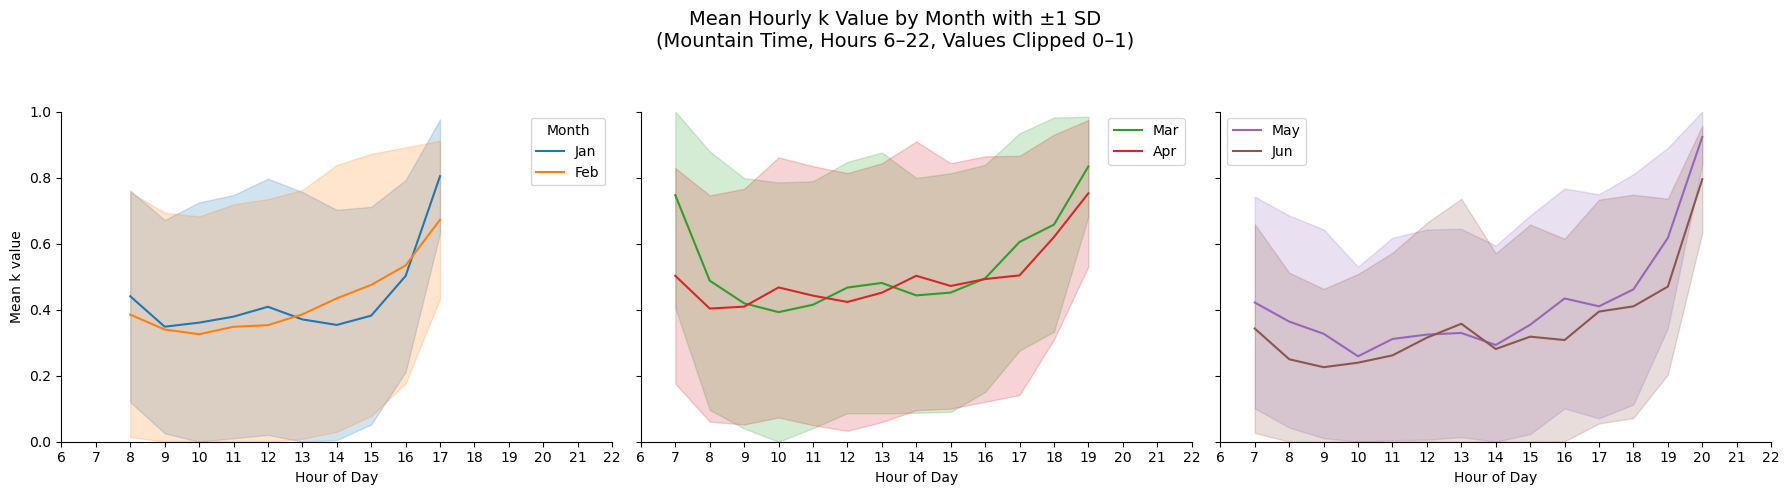

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare DataFrame
df = pd.DataFrame({
    'time': pd.to_datetime(irwin_k.time),
    'k': irwin_k.values
})

# Convert to Mountain Time
df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

# Clean data
df = df.dropna(subset=['k'])
df = df[df['k'] != 0]

# Extract hour and month
df['hour'] = df['time'].dt.hour
df['month_num'] = df['time'].dt.month

# Define target months and mapping
month_map = {
    1: 'Jan', 2: 'Feb',
    3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun'
}
df = df[df['month_num'].isin(month_map.keys())]
df['month'] = df['month_num'].map(month_map)

# Filter hours
df = df[(df['hour'] >= 5) & (df['hour'] <= 22)]

# Compute mean and std grouped by month and hour
grouped = df.groupby(['month', 'hour'])['k'].agg(['mean', 'std']).reset_index()

# Ensure correct order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
grouped['month'] = pd.Categorical(grouped['month'], categories=month_order, ordered=True)
grouped = grouped.sort_values(['month', 'hour'])

# Limit values between 0 and 1
grouped['mean'] = grouped['mean'].clip(0, 1)
grouped['std'] = grouped['std'].clip(0, 1)

# Subplot layout: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Month groups per panel
panels = {
    0: ['Jan', 'Feb'],
    1: ['Mar', 'Apr'],
    2: ['May', 'Jun']
}

# Unique colors for each month
month_colors = {
    'Jan': '#1f77b4',  # blue
    'Feb': '#ff7f0e',  # orange
    'Mar': '#2ca02c',  # green
    'Apr': '#d62728',  # red
    'May': '#9467bd',  # purple
    'Jun': '#8c564b'   # brown
}

# Plot each panel
for ax_idx, months in panels.items():
    ax = axes[ax_idx]
    for month in months:
        month_data = grouped[grouped['month'] == month]
        color = month_colors[month]
        
        # Plot mean line
        ax.plot(month_data['hour'], month_data['mean'], label=month, color=color)
        
        # Plot ±1 std shading, clipped to [0, 1]
        lower = (month_data['mean'] - month_data['std']).clip(0, 1)
        upper = (month_data['mean'] + month_data['std']).clip(0, 1)
        ax.fill_between(month_data['hour'], lower, upper, alpha=0.2, color=color)

    # Format subplot
    # ax.set_title(f"{' & '.join(months)}")
    ax.set_xlabel("Hour of Day")
    ax.set_xticks(range(6, 23))
    ax.set_xlim(6, 22)
    ax.set_ylim(0, 1)
    ax.set_facecolor('white')
    ax.tick_params(axis='both', direction='out')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared y-label
axes[0].set_ylabel("Mean k value")

# Legend on first subplot
axes[0].legend(title='Month')
axes[1].legend(title='')
axes[2].legend(title='')

plt.suptitle("Mean Hourly k Value by Month with ±1 SD\n(Mountain Time, Hours 6–22, Values Clipped 0–1)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [36]:
import pandas as pd

# Convert irwin_k.time to datetime with timezone info (Mountain Time)
times_local = pd.to_datetime(irwin_k.time).tz_localize('UTC').tz_convert('America/Denver')

# Extract hours
hours_local = times_local.hour

# Filter irwin_k values where hour == 6
values_at_6am = irwin_k[hours_local == 6]

print(f"Number of irwin_k values at 6 AM local time: {len(values_at_6am)}")
print(values_at_6am.head())


Number of irwin_k values at 6 AM local time: 305
<xarray.DataArray 'k' (time: 5)> Size: 20B
array([0., 0., 0., 0., 0.], dtype=float32)
Coordinates:
    x        float32 4B 3.171e+05
    y        float32 4B 4.306e+06
  * time     (time) datetime64[ns] 40B 2021-09-30T12:00:00 ... 2021-10-04T12:...
Attributes:
    units:         None
    description:   Fraction of diffuse/global in the visible
    grid_mapping:  projection


In [ ]:
# Use Dask-aware xarray reductions
k = irwin_k

k_stats = {
    'min': k.min().compute().item(),
    'max': k.max().compute().item(),
    'mean': k.mean().compute().item(),
    'median': k.median().compute().item(),
    'std': k.std().compute().item(),
    '25th percentile': k.quantile(0.25).compute().item(),
    '75th percentile': k.quantile(0.75).compute().item(),
    'count (non-NaN)': k.count().compute().item(),
    'NaN count': k.size - k.count().compute().item()
}

# Print nicely
print("Global Statistics for k:")
for key, val in k_stats.items():
    print(f"{key:>18}: {val:.4f}")


In [ ]:
import dask.array as da
import numpy as np
import matplotlib.pyplot as plt

# Assume HRRR_solar is your xarray dataset
# Get the 'k' variable (using Dask array)
k_data = HRRR_solar['k']

# Calculate the mean of 'k' across the time axis (axis 0)
# This will result in a (y, x) array of the mean values
mean_k = k_data.mean(axis=0).compute()  # .compute() triggers the actual computation

# Plot the mean 'k' value (time-averaged) as an image
plt.figure(figsize=(10, 6))
plt.imshow(mean_k, cmap='viridis', origin='lower')
plt.colorbar(label='Mean K (%)')
plt.title('Mean K Value Across Time')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.tight_layout()
plt.show()
